# 다중 회귀와 예측 결과 분석

> 여러 입력 변수를 함께 사용해 더 정확한 회귀 모델을 만들고, 예측 결과를 깊이 있게 분석합니다.

| 구분 | 입력 변수 개수 | 예측식 |
| 단순 회귀 | 1개 | `점수 = a x 공부 시간 + b` |
| 다중 회귀 | 여러 개 | `점수 = a(1) x 공부시간 + a(2) x 출석률 + a(3) x 과제 점수 + b`|

-> 각 변수마다 자신의 계수(coef, 가중치)를 갖고 , 모든 항을 더한 뒤 마지막 절편(inrerp_)을 더해 예측값을 만든다.

## 라이브러리 불러오기

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score  

# 실습데이터 : 학생 성적 데이터

In [16]:
student_df = pd.DataFrame({
    # 하루 평균 공부 시간
    "study_hours": [1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 8, 8, 9, 9, 10, 10, 11],
    # 출석률
    "attendance": [50, 55, 60, 58, 65, 70, 72, 75, 78, 80, 82, 85, 88, 90, 92, 93, 95, 96, 97, 98],
    # 과제 점수
    "assignment": [40, 45, 50, 52, 55, 60, 63, 68, 70, 75, 78, 82, 85, 88, 90, 92, 94, 95, 96, 98],
    # 최종 시험 점수, 모델이 예측해야 할 값
    "score": [45, 50, 53, 56, 60, 64, 67, 70, 73, 76, 79, 82, 85, 88, 90, 92, 94, 95, 96, 98]
})

student_df.head()

,study_hours,attendance,assignment,score
0,1,50,40,45
1,2,55,45,50
2,2,60,50,53
3,3,58,52,56
4,3,65,55,60


# 데이터 살펴보기


In [17]:
student_df.describe()

,study_hours,attendance,assignment,score
count,20.000000,20.000000,20.000000,20.000000
mean,6.000000,78.950000,73.800000,75.650000
std,2.991215,15.226276,18.729656,16.828156
min,1.000000,50.000000,40.000000,45.000000
25%,3.750000,68.750000,58.750000,63.000000
50%,6.000000,81.000000,76.500000,77.500000
75%,8.250000,92.250000,90.500000,90.500000
max,11.000000,98.000000,98.000000,98.000000


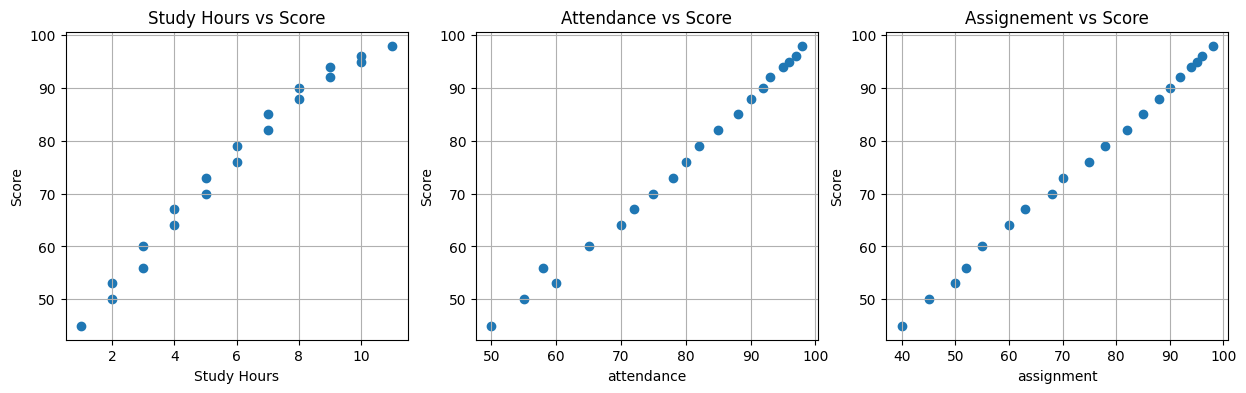

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))

axes[0].scatter(student_df['study_hours'],student_df['score'])
axes[0].set_title('Study Hours vs Score')
axes[0].set_xlabel('Study Hours')
axes[0].set_ylabel('Score')
axes[0].grid(True)

axes[1].scatter(student_df['attendance'],student_df['score'])
axes[1].set_title('Attendance vs Score')
axes[1].set_xlabel('attendance')
axes[1].set_ylabel('Score')
axes[1].grid(True)

axes[2].scatter(student_df['assignment'],student_df['score'])
axes[2].set_title('Assignement vs Score')
axes[2].set_xlabel('assignment')
axes[2].set_ylabel('Score')
axes[2].grid(True)


## 단순 회귀 모델 만들기 (비교용 베이스 라인)

다중 회귀와 성능을 비교할 때 기준점(bassLine)으로 사용

In [19]:
X = student_df[['study_hours']]
y = student_df['score']

print('X 모양:' , X.shape)
print('y 모양:' , y.shape)

X 모양: (20, 1)
y 모양: (20,)


In [24]:
X_train , X_test, y_train, y_test = train_test_split(
    X,y,
    test_size=0.3,
    random_state=42
)

print('훈련 데이터 개수:', len(X_train))
print('테스트 데이터 개수:', len(X_test))

model = LinearRegression()
model.fit(X_train, y_train)

print('모델 학습 완료')
print(f'기울기: {model.coef_[0]:.3f}')
print(f'절편: {model.intercept_:.3f}')

pred = model.predict(X_test)
print('예측완료')


훈련 데이터 개수: 14
테스트 데이터 개수: 6
모델 학습 완료
기울기: 5.393
절편: 43.858
예측완료


In [26]:
X_multi = student_df[['study_hours' , 'attendance' , 'assignment']]
y_multi = student_df['score']

print('X_multi 모양:' , X_multi.shape)
print('y_multi 모양:' , y_multi.shape)

X_train_m, X_test_m , y_train_m , y_test_m = train_test_split(
    X_multi, y_multi,
    test_size=0.3,
    random_state=42
)

multi_model = LinearRegression()
multi_model.fit(X_train_m, y_train_m)

print('다중 회귀 모델 학습 완료')

X_multi 모양: (20, 3)
y_multi 모양: (20,)
다중 회귀 모델 학습 완료


## 다중 회귀 모델의 계수 해석하기

예측 점수 = a(1) x study_hours
        + a(2) x attendance
        + a(3) xassignment
        + b (절편)

`a(1)` , `a(2)` , `a(3)` 은 각 변수의 계수(coef_), `b` 는 절편
(intercept_)

각 계수의 의미: 다른 변수가 모두 그대로일 때, 해당 변수가 1만큼 증가하면서 예측 점수가 계수만큼 변한다.
단 , 변수마다 단위가 다르므로 **계수의 절댓값만 보고 변수의 중요도를 비교하면 안된다.**


In [28]:
coef_df = pd.DataFrame({
    'feature': X_multi.columns,
    'coefficient': multi_model.coef_,
})

print(f'절편: {multi_model.intercept_:.3f}')
coef_df

절편: 8.372


,feature,coefficient
0,study_hours,0.840803
1,attendance,0.302282
2,assignment,0.519798


- `study_hours`의 계수가 양수이면 , 공부시간 1시간 늘어날 때 예측 점수가 
그만큼 올라간다는 뜻
- `attendance`의 계수가 양수이면 , 출석률 1%p 늘어날 때 예측 점수가 그만큼 올라간다.
- `assignment` 의 계수가 양수이면 , 과제점수가 1점 늘어날 때 예측 점수가 그만큼 올라간다.

만약 어떤 계수가 **음수**라면 , 그 변수가 커질수록 예측값은 작아진다.


## 문제 

위에 얻은 계수와 절편을 이용해, 다음 학생의 예측 점수를 계산한다.

- `study_hours` = 6 
- `attendance` = 80
- `assignment` = 75

예측 점수 =
study_hours 계수 X 6
    + attendance 계수 x 80
    + assignment 계수 X 75
    + 절편

## 단순 회귀 vs 다중 회귀 성능 비교

- `MAE` : 평균적으로 몇 점 차이로 틀리는가 (작을수록 좋음)
- `R2` : 모델이 점수의 변화를 얼마나 잘 설명하는가 (1에 가까울수록 좋음)

In [33]:
multi_pred = multi_model.predict(X_test_m)

simple_mae = mean_absolute_error(y_test , pred)
simple_r2 = r2_score(y_test, pred)

multi_mae = mean_absolute_error(y_test_m , multi_pred)
multi_r2 = r2_score(y_test_m , multi_pred)

compare_df = pd.DataFrame({
    'model': ['study_hours only' , 'study_hours + attebdabce + assignment'],
    'MAE': [simple_mae, multi_mae],
    'R2': [simple_r2, multi_r2]
})

compare_df

,model,MAE,R2
0,study_hours only,2.614622,0.975050
1,study_hours + attebdabce + assignment,0.173205,0.999869


결과 해석

- 다중 회귀의 ` MAE` 가 단순 회귀 보다 훨씬 작다 -> 평균 오차가 더 작다는 뜻
- 다중 회귀의 `R2` 가 단순 호귀보다 1에 더 가깝다 -> 데이터의 패턴을 더잘 설명한다는 뜻

이는 **출석률** 과 **과제점수**가 단순히 "공부시간으로는 설명되지 않는 추가정부"를 모델에 제공했기 때문입니다.

> **주의** - 변수를 무조건 많이 넣는다고 항상 좋아지지는 않습니다. 의미 없는 변수가 들어오면 오히려 Noise 가 늘어나 성능이 떨어지거나 (과적합), 결과 해석이 어려워질 수 있습니다.
머신러닝 과목에서 `변수 선택(feture selection)` 으로 깊이 다룹니다.